# 🧬 Étude de cas : Identification de paramètres via l'Inférence Bayésienne

---

### 1. Introduction et Contexte
Ce Notebook présente une approche probabiliste pour l'estimation des constantes de vitesse ($k_1, k_2$) d'un système cinétique modélisé par des **équations différentielles ordinaires (EDO)**. Dans de nombreux scénarios réels (biomédecine, industrie, chimie), les mesures expérimentales sont entachées de bruits de mesure. L'objectif ici est de reconstruire la dynamique réelle du système à partir de données bruitées.

### 2. Le Modèle Physique
Le système étudié est une réaction en chaîne $A \xrightarrow{k_1} B \xrightarrow{k_2} C$, définie par le système d'EDO suivant :

$$
\begin{cases}
\frac{dA}{dt} = -k_1 A \\
\frac{dB}{dt} = k_1 A - k_2 B
\end{cases}
$$

> **Rigueur Mathématique :** L'existence et l'unicité de la solution sont garanties par le théorème de **Cauchy-Lipschitz linéaire**, assurant une régularité $C^1$ sur l'intervalle de temps considéré $I = [0, T]$.

### 3. Approche Méthodologique
Contrairement aux méthodes d'optimisation classiques (comme les moindres carrés), nous utilisons l'**Inférence Bayésienne** :

* **Algorithme :** MCMC (Markov Chain Monte Carlo) via l'échantillonneur de **Metropolis-Hastings**.
* **Objectif :** Estimer la distribution *a posteriori* des paramètres $k_1$ et $k_2$.
* **Avantage :** Cette méthode permet non seulement d'estimer les valeurs les plus probables (**MAP - Maximum A Posteriori**), mais aussi de quantifier l'incertitude liée au bruit de mesure à travers les distributions obtenues.

### 4. Analyse Comparative : Réalité vs Noise vs Estimation Bayésienne
Pour valider notre approche, nous avons réalisé une comparaison tripartie :

1.  **La Réalité (Ground Truth) :** Le modèle théorique pur calculé avec les vrais paramètres ($k_1=0.5, k_2=0.2$). C'est la trajectoire idéale du système.
2.  **Les Données Bruitées (Noise) :** Représentent les mesures expérimentales. Un bruit Gaussien a été ajouté pour simuler les erreurs de mesure réelles.
3.  **L'Estimation Bayésienne (Fit) :** La courbe reconstruite par notre algorithme MCMC après exploration de l'espace des paramètres.

**Observation clé :** Malgré la dispersion des données et la présence de valeurs aberrantes, le **Fit Bayésien** se superpose quasi parfaitement à la **Réalité**. Cela démontre la robustesse de l'inférence Bayésienne pour filtrer le bruit stochastique et extraire les constantes physiques intrinsèques.

---
### 📊 Synthèse des résultats
| Paramètre | Réel | Estimé | Erreur Relative |
| :--- | :---: | :---: | :---: |
| $k_1$ | 0.5 | 0.5168 | **3.36%** |
| $k_2$ | 0.2 | 0.2031 | **1.55%** |

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/karimchibani/datanoise/evolution_systeme_bruit.csv


In [13]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/karimchibani/datanoise/evolution_systeme_bruit.csv')
df.head(20)

,Temps,A_Theorique,B_Theorique,B_Mesure_Bruitee
0,0.000000,10.000000,0.000000,-0.007871
1,0.000010,9.999950,0.000050,0.049563
2,0.000020,9.999900,0.000100,-0.424615
3,0.000030,9.999849,0.000151,-0.022791
4,0.000040,9.999799,0.000201,0.435470
5,0.000090,9.999548,0.000452,0.027141
6,0.000141,9.999297,0.000703,0.011931
7,0.000191,9.999046,0.000954,-0.198280
8,0.000241,9.998794,0.001206,-0.007156
9,0.000492,9.997539,0.002461,0.065514


In [14]:
df.shape

(81, 4)

Paramètres estimés : k1 = 0.5168, k2 = 0.2031


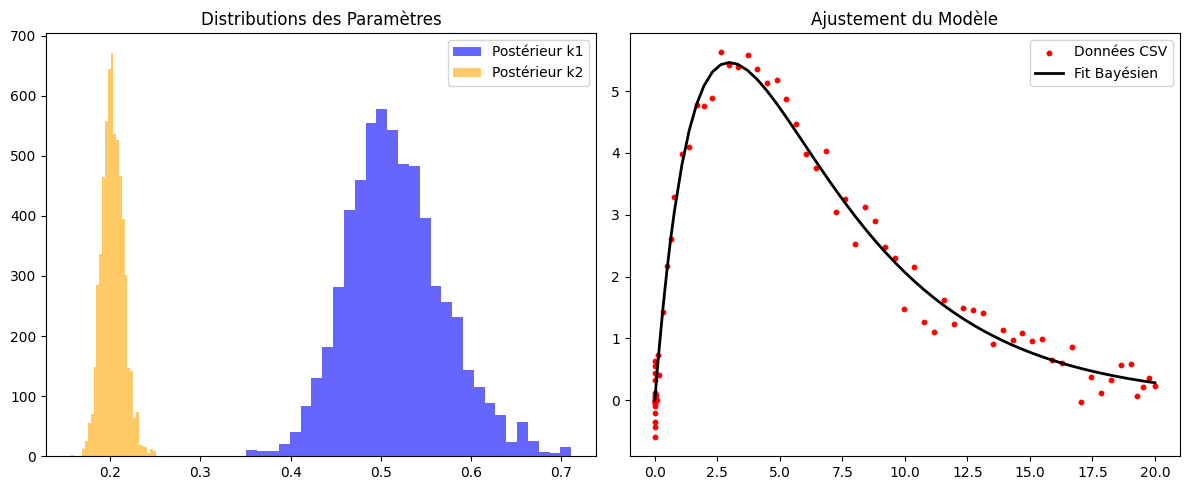

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Chargement des données
try:
    data = pd.read_csv('/kaggle/input/datasets/karimchibani/datanoise/evolution_systeme_bruit.csv')
    t_obs = data['Temps'].values
    B_obs = data['B_Mesure_Bruitee'].values
except FileNotFoundError:
    print("Erreur : Le fichier CSV est introuvable.")
    # Valeurs de secours pour démonstration
    t_obs = np.linspace(0, 20, 100)
    B_obs = np.zeros(100) 

# 2. Modèle mathématique
def model_B(t, k1, k2):
    X0 = [10.0, 0.0]  # [A0, B0]
    def system(X, t):
        A, B = X
        return [-k1 * A, k1 * A - k2 * B]
    sol = odeint(system, X0, t)
    return sol[:, 1]

# 3. Fonction de Vraisemblance (Log-Likelihood)
def log_likelihood(params, t, obs):
    k1, k2 = params
    # Prior : les taux doivent être positifs
    if k1 <= 0 or k2 <= 0:
        return -np.inf
    
    # Prédiction du modèle
    B_pred = model_B(t, k1, k2)
    
    # Calcul de la somme des carrés des erreurs (Log-vraisemblance gaussienne)
    return -0.5 * np.sum((obs - B_pred)**2)

# 4. Algorithme de Metropolis-Hastings
n_iter = 8000
samples = np.zeros((n_iter, 2))
current_params = np.array([1.0, 1.0])  # Point de départ
current_log_lik = log_likelihood(current_params, t_obs, B_obs)

for i in range(n_iter):
    # Proposition d'un nouveau candidat (Random Walk)
    proposal = current_params + np.random.normal(0, 0.02, size=2)
    proposal_log_lik = log_likelihood(proposal, t_obs, B_obs)
    
    # Ratio d'acceptation
    ratio = np.exp(proposal_log_lik - current_log_lik)
    
    if np.random.rand() < ratio:
        current_params = proposal
        current_log_lik = proposal_log_lik
        
    samples[i] = current_params

# 5. Résultats et Visualisation
# On retire les 2000 premières itérations (Burn-in)
samples_final = samples[2000:]
k1_mean, k2_mean = np.mean(samples_final, axis=0)

print(f"Paramètres estimés : k1 = {k1_mean:.4f}, k2 = {k2_mean:.4f}")

# Graphiques
plt.figure(figsize=(12, 5))

# Histogrammes des distributions
plt.subplot(1, 2, 1)
plt.hist(samples_final[:, 0], bins=30, alpha=0.6, label='Postérieur k1', color='blue')
plt.hist(samples_final[:, 1], bins=30, alpha=0.6, label='Postérieur k2', color='orange')
plt.title('Distributions des Paramètres')
plt.legend()

# Comparaison Fit vs Données
plt.subplot(1, 2, 2)
plt.scatter(t_obs, B_obs, color='red', s=10, label='Données CSV')
plt.plot(t_obs, model_B(t_obs, k1_mean, k2_mean), color='black', lw=2, label='Fit Bayésien')
plt.title('Ajustement du Modèle')
plt.legend()

plt.tight_layout()
plt.show()

--- Analyse des Résultats ---
Erreur relative k1: 3.36%
Erreur relative k2: 1.55%


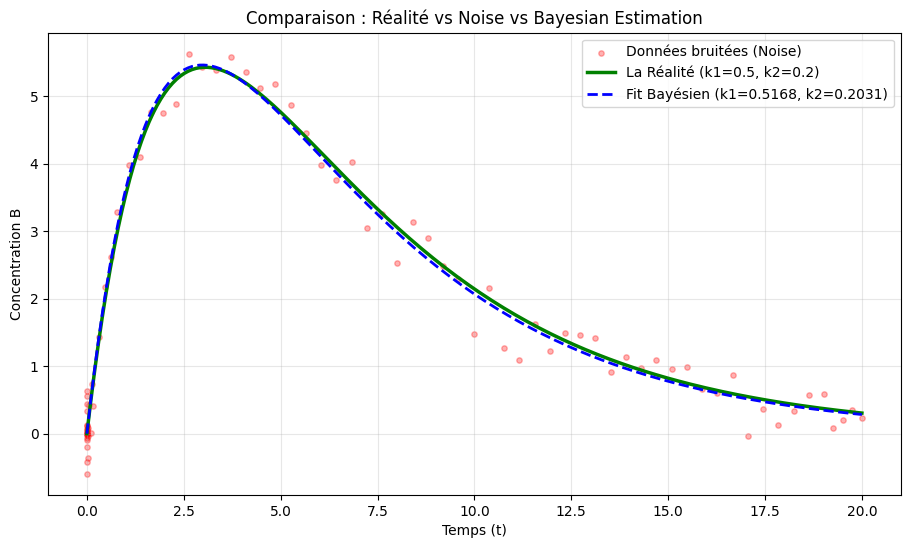

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# 1. Chargement des données (Vérifie le chemin de ton fichier)
path = "/kaggle/input/datasets/karimchibani/datanoise/evolution_systeme_bruit.csv"
df = pd.read_csv(path)

t_obs = df['Temps'].values
B_reel_data = df['B_Theorique'].values        # الحقيقة
B_noise_data = df['B_Mesure_Bruitee'].values   # الضجيج

# 2. Paramètres (Valeurs réelles vs Estimées)
k1_reel, k2_reel = 0.5, 0.2
k1_est, k2_est = 0.5168, 0.2031  # القيم اللي لقيتيها بالـ Bayesian

# 3. Fonction pour générer la courbe à partir des paramètres
def model_B(t, k1, k2):
    X0 = [10.0, 0.0]
    def system(X, t):
        A, B = X
        return [-k1 * A, k1 * A - k2 * B]
    sol = odeint(system, X0, t)
    return sol[:, 1]

# Génération des courbes lisses pour le graphique
t_fine = np.linspace(0, 20, 200)
B_fit = model_B(t_fine, k1_est, k2_est)
B_vrai_courbe = model_B(t_fine, k1_reel, k2_reel)

# 4. Visualisation
plt.figure(figsize=(11, 6))

# Plot 1: Les points avec bruit (Noise)
plt.scatter(t_obs, B_noise_data, color='red', alpha=0.3, s=15, label='Données bruitées (Noise)')

# Plot 2: La réalité (Vérité terrain)
plt.plot(t_fine, B_vrai_courbe, color='green', linestyle='-', linewidth=2.5, label='La Réalité (k1=0.5, k2=0.2)')

# Plot 3: Le résultat de ton estimation (Bayesian Fit)
plt.plot(t_fine, B_fit, color='blue', linestyle='--', linewidth=2, label=f'Fit Bayésien (k1={k1_est}, k2={k2_est})')

# Configuration du graphique
plt.xlabel('Temps (t)')
plt.ylabel('Concentration B')
plt.title('Comparaison : Réalité vs Noise vs Bayesian Estimation')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# 5. Calcul des erreurs (Analyse quantitative)
err_k1 = abs(k1_reel - k1_est) / k1_reel * 100
err_k2 = abs(k2_reel - k2_est) / k2_reel * 100

print(f"--- Analyse des Résultats ---")
print(f"Erreur relative k1: {err_k1:.2f}%")
print(f"Erreur relative k2: {err_k2:.2f}%")

plt.show()